In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df_tripletas = pd.read_csv("./datos/tripletas_generadas.csv")
df_silver = pd.read_csv("./datos/tripletas_aceptadas.csv")
# Creamos un grafo dirigido las relaciones tienen dirección: Investigador -> Topic
G = nx.DiGraph()

# Poblamos el grafo con los datos del DataFrame
for index, row in df_tripletas.iterrows():
    investigador = row['nombre_investigador']
    topico = str(row['topico']).title()
    relacion = row['relacion']

    if not G.has_node(investigador):
        G.add_node(investigador, tipo="Investigador", id_url=row['investigador_id'])

    if not G.has_node(topico):
        G.add_node(topico, tipo="Tópico")

    G.add_edge(investigador, topico, tipo_relacion=relacion, evidencia=row['evidencia'])

print(f"Grafo construido: {G.number_of_nodes()} Nodos y {G.number_of_edges()} Aristas.")

Grafo construido: 413 Nodos y 287 Aristas.


In [24]:

#Se pueden hacer algunas preguntas como:

#  ¿Cuáles son los investigadores mas conectados?

grados_investigadores = [
    (nodo, grado) for nodo, grado in G.out_degree()
    if G.nodes[nodo].get('tipo') == 'Investigador'
]
top_conectados = sorted(grados_investigadores, key=lambda x: x[1], reverse=True)[:10]
print("\nInvestigadores con más diversidad de temas:")
for inv, grado in top_conectados:
    print(f" - {inv}: {grado} conexiones")

#  ¿Cuáles son los tópicos puente (los más investigados en común)?
grados_topicos = [
    (nodo, grado) for nodo, grado in G.in_degree()
    if G.nodes[nodo].get('tipo') == 'Tópico'
]
topicos_puente = sorted(grados_topicos, key=lambda x: x[1], reverse=True)[:10]
print("\nTópicos centrales de la Universidad:")
for top, grado in topicos_puente:
    print(f" - {top}: {grado} investigadores vinculados")


Investigadores con más diversidad de temas:
 - NOEMI PINILLA ALONSO: 6 conexiones
 - Borja Jiménez-Alfaro: 5 conexiones
 - JAVIER DE ANDRES SUAREZ: 4 conexiones
 - MIGUEL ENRIQUE DEL VALLE SOTO: 4 conexiones
 - EDUARDO FERNANDEZ ALONSO: 4 conexiones
 - RUBEN MARTIN PAYO: 4 conexiones
 - MARIA DEL MAR FERNANDEZ ALVAREZ: 4 conexiones
 - DAVID ALVAREZ FERNANDEZ: 4 conexiones
 - NEREA LOPEZ BOUZAS: 4 conexiones
 - MARCOS MIÑARRO PRADO: 4 conexiones

Tópicos centrales de la Universidad:
 - Divulgación Científica: 6 investigadores vinculados
 - Tratamientos Para Dejar De Fumar: 5 investigadores vinculados
 - Red 5G: 5 investigadores vinculados
 - Semana De La Ciencia: 5 investigadores vinculados
 - Exposición Sobre Análisis Input-Output: 4 investigadores vinculados
 - Impacto De Contaminantes Emergentes En Ecosistemas Marinos: 4 investigadores vinculados
 - Modelo Estadístico: 4 investigadores vinculados
 - Convocatoria De Redes: 4 investigadores vinculados
 - Impacto De La Fauna Silvestre 

📊 GRAFO DE CONOCIMIENTO ZERO-SHOT
• Nodos totales: 413 (Investigadores + Tópicos)
• Aristas totales (Tripletas): 287

Knowledge Hubs / topics:
  - Divulgación Científica: 6 investigadores
  - Tratamientos Para Dejar De Fumar: 5 investigadores
  - Red 5G: 5 investigadores
  - Semana De La Ciencia: 5 investigadores
  - Exposición Sobre Análisis Input-Output: 4 investigadores

 Top Investigadores:
  - Noemi Pinilla Alonso: 6 tópicos
  - Borja Jiménez-Alfaro: 5 tópicos
  - Javier De Andres Suarez: 4 tópicos
  - Miguel Enrique Del Valle Soto: 4 tópicos
  - Eduardo Fernandez Alonso: 4 tópicos




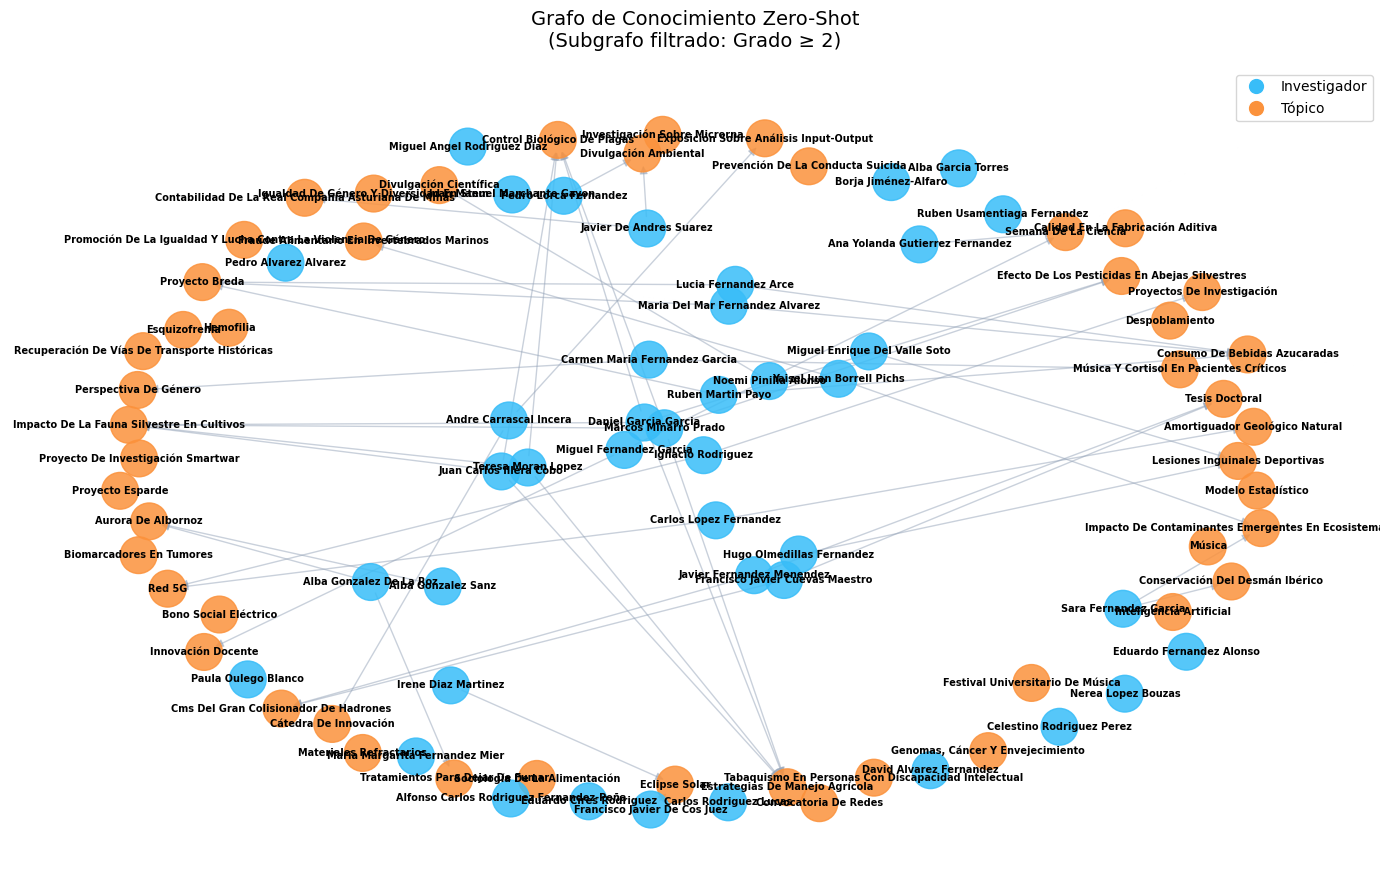

📊 GRAFO DE CONOCIMIENTO SILVER
• Nodos totales: 146 (Investigadores + Tópicos)
• Aristas totales (Tripletas): 90

Knowledge Hubs / topics:
  - Semana De La Ciencia: 5 investigadores
  - Proyecto Esparde: 3 investigadores
  - Red 5G: 3 investigadores
  - Contabilidad De La Real Compañía Asturiana De Minas: 2 investigadores
  - Cátedra De Innovación: 2 investigadores

 Top Investigadores:
  - Nerea Lopez Bouzas: 4 tópicos
  - Javier De Andres Suarez: 3 tópicos
  - Ruben Usamentiaga Fernandez: 3 tópicos
  - Eduardo Fernandez Alonso: 3 tópicos
  - Borja Jiménez-Alfaro: 3 tópicos




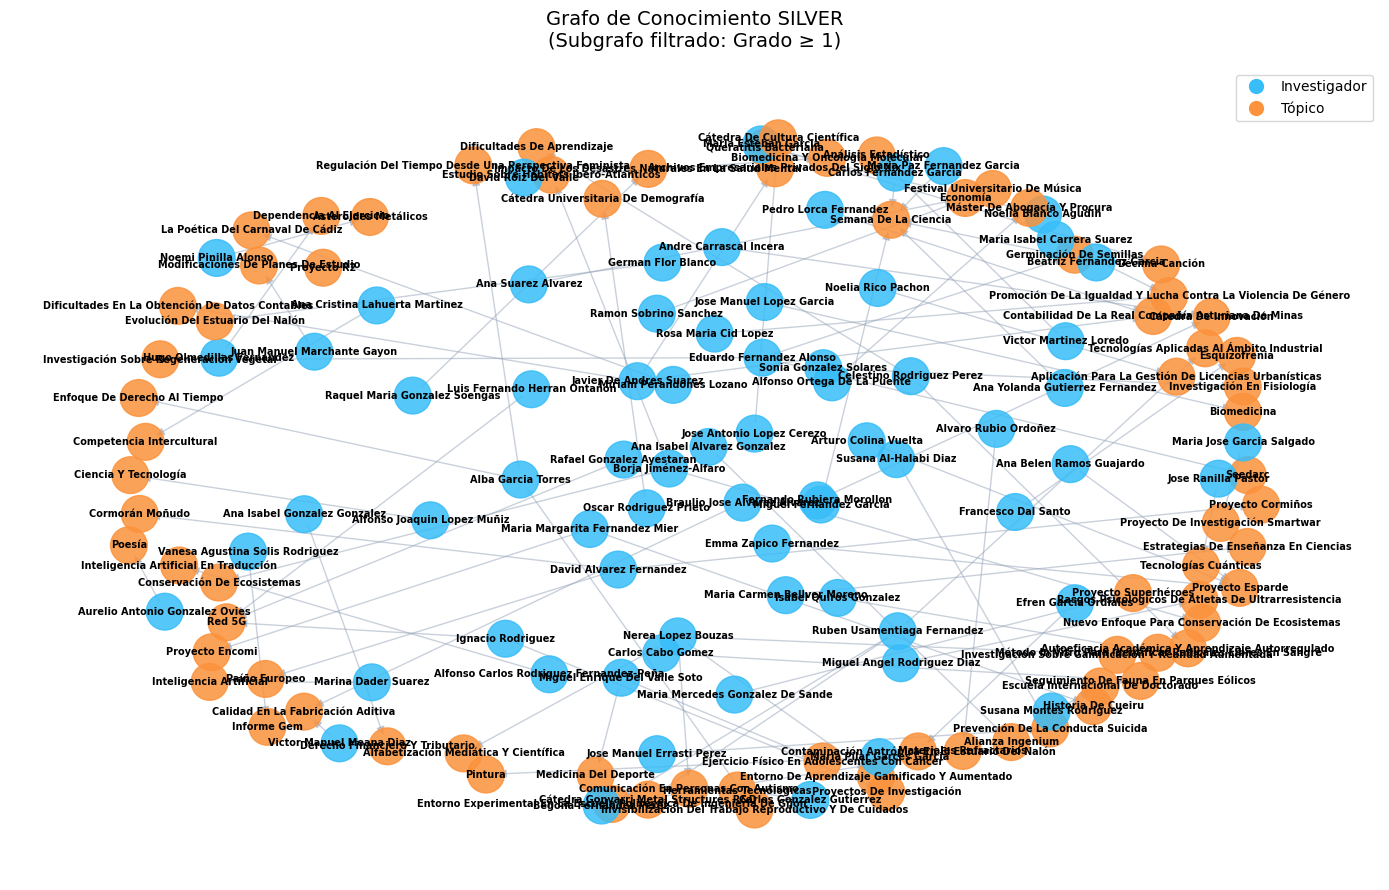

In [ ]:

def generar_y_comparar_grafos(df_raw, df_silver, min_grado_raw=2, min_grado_silver=1):
    """
    Construye, analiza y visualiza los grafos de conocimiento para las tripletas RAW y SILVER.
    """
    
    def procesar_grafo(df, titulo, min_grado):
        G = nx.DiGraph()
        
        # Determinar columna de nombre del investigador
        col_inv = 'nombre_investigador' if 'nombre_investigador' in df.columns else 'investigador_id'
        
        for _, row in df.iterrows():
            inv = str(row[col_inv]).title()
            top = str(row['topico']).title()
            rel = str(row['relacion'])

            G.add_node(inv, type='Researcher')
            G.add_node(top, type='Topic')
            G.add_edge(inv, top, relation=rel)

        # Cálculo de centralidad
        researcher_degrees = {n: G.out_degree(n) for n, d in G.nodes(data=True) if d['type'] == 'Researcher'}
        topic_degrees = {n: G.in_degree(n) for n, d in G.nodes(data=True) if d['type'] == 'Topic'}

        top_researchers = sorted(researcher_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        top_topics = sorted(topic_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

        print(f"==================================================")
        print(f"📊 {titulo.upper()}")
        print(f"==================================================")
        print(f"• Nodos totales: {G.number_of_nodes()} (Investigadores + Tópicos)")
        print(f"• Aristas totales (Tripletas): {G.number_of_edges()}")
        
        print("\nKnowledge Hubs / topics:")
        for topic, count in top_topics:
            print(f"  - {topic}: {count} investigadores")

        print("\n Top Investigadores:")
        for res, count in top_researchers:
            print(f"  - {res}: {count} tópicos")
        print("\n")

        # Visualización
        sub_nodes = [n for n, d in G.degree() if d >= min_grado]
        subgraph = G.subgraph(sub_nodes)

        plt.figure(figsize=(14, 9))
        pos = nx.spring_layout(subgraph, k=0.55, iterations=60, seed=42)

        colors = ['#38bdf8' if subgraph.nodes[n]['type'] == 'Researcher' else '#fb923c' for n in subgraph.nodes()]

        nx.draw_networkx_nodes(subgraph, pos, node_color=colors, node_size=700, alpha=0.85)
        nx.draw_networkx_edges(subgraph, pos, edge_color='#94a3b8', alpha=0.5, arrows=True, arrowsize=12)
        nx.draw_networkx_labels(subgraph, pos, font_size=7, font_weight='bold')

        plt.title(f"{titulo}\n(Subgrafo filtrado: Grado ≥ {min_grado})", fontsize=14, pad=15)
        
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', label='Investigador', markerfacecolor='#38bdf8', markersize=12),
            plt.Line2D([0], [0], marker='o', color='w', label='Tópico', markerfacecolor='#fb923c', markersize=12)
        ]
        plt.legend(handles=legend_elements, loc='upper right')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        return G

    # 1. Grafo de tripletas sin limpiar o RAW
    G_raw = procesar_grafo(df_raw, "Grafo de Conocimiento Zero-Shot", min_grado=min_grado_raw)
    
    # 2. Grafo Silver con tripletas limpias y aceptadas por los 6 filtros
    G_silver = procesar_grafo(df_silver, "Grafo de Conocimiento SILVER", min_grado=min_grado_silver)
    
    return G_raw, G_silver

G_raw, G_silver = generar_y_comparar_grafos(df_tripletas, df_silver, min_grado_raw=2, min_grado_silver=1)

Vamos a añadir el nombre de las artistas, y ademas ver si somos capaces de separar un poco todo para que se lea bien de cara al paper. 

GRAFO ZERO-SHOT (RAW)
• Nodos totales: 413
• Aristas totales (Tripletas): 287


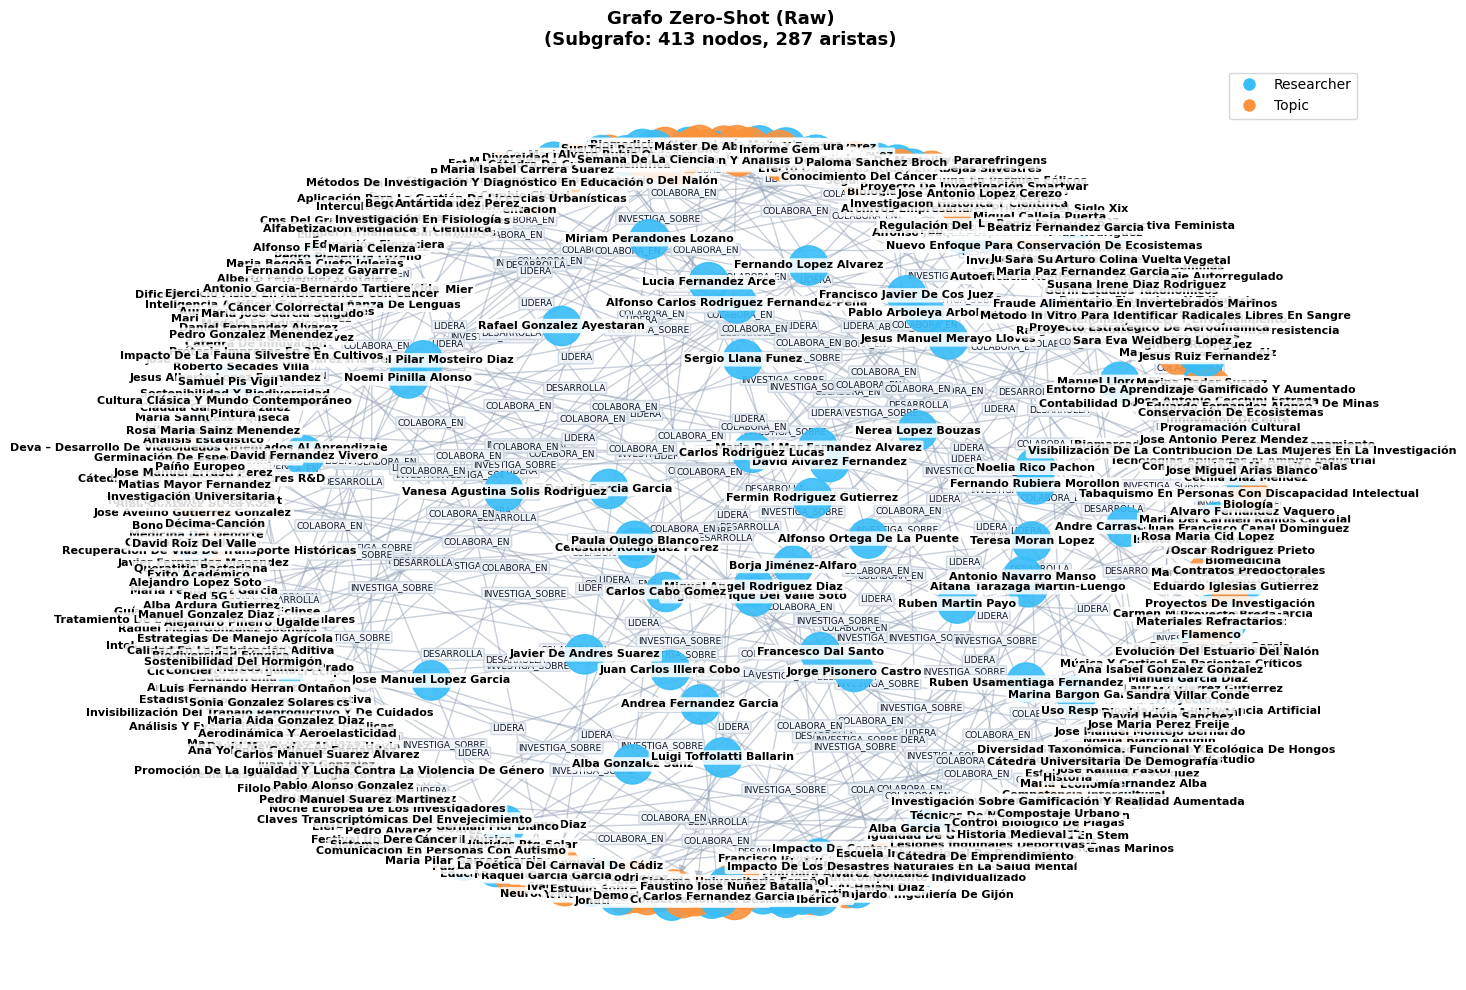

GRAFO SILVER
• Nodos totales: 146
• Aristas totales (Tripletas): 90


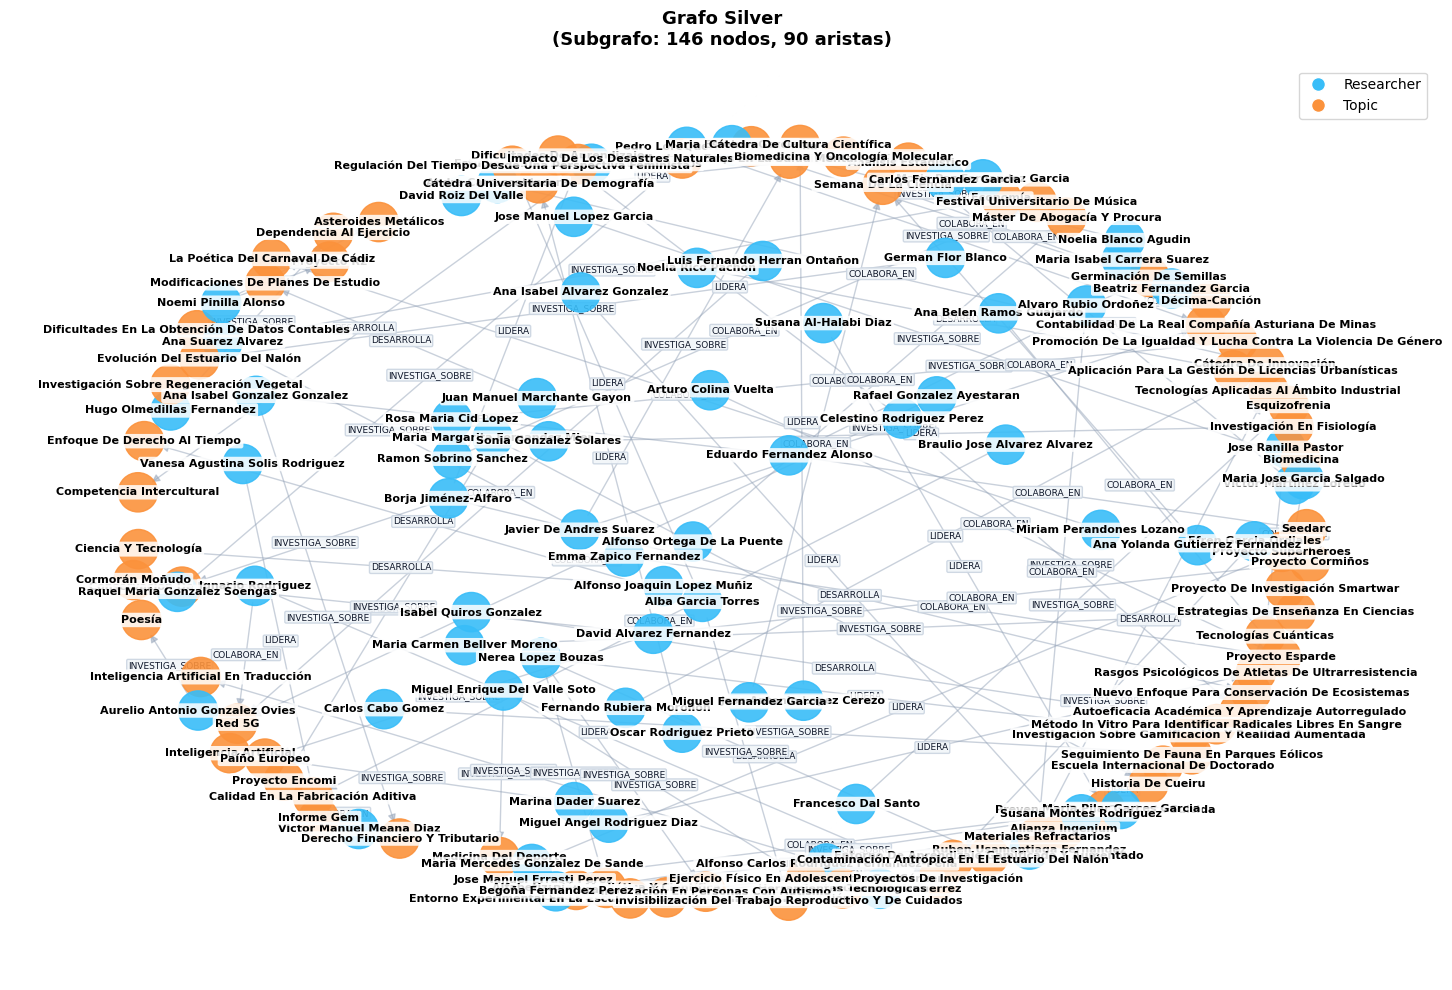

In [21]:


def generar_y_comparar_grafos(
    df_raw, df_silver, min_grado_raw=2, min_grado_silver=1
):
    """Construye y visualiza los grafos de conocimiento validando la existencia de datos."""

    def procesar_grafo(df, titulo, min_grado):
        if df is None or df.empty:
            print(
                f"⚠️ El DataFrame para '{titulo}' está vacío. No se puede generar el grafo."
            )
            return nx.DiGraph()

        G = nx.DiGraph()

        # Detección flexible de columnas
        col_inv = next(
            (
                c
                for c in [
                    "nombre_investigador",
                    "investigador_id",
                    "investigador",
                    "subject",
                ]
                if c in df.columns
            ),
            None,
        )
        col_top = next(
            (
                c
                for c in [
                    "topico_canonico",
                    "topico",
                    "topic",
                    "objeto",
                    "object",
                ]
                if c in df.columns
            ),
            None,
        )
        col_rel = next(
            (
                c
                for c in ["relacion", "relation", "predicado", "predicate"]
                if c in df.columns
            ),
            None,
        )

        if not col_inv or not col_top or not col_rel:
            print(
                f"Columnas no encontradas en {titulo}. Columnas disponibles: {list(df.columns)}"
            )
            return G

        # Limpieza e inserción de datos
        for _, row in df.dropna(
            subset=[col_inv, col_top, col_rel]
        ).iterrows():
            inv = str(row[col_inv]).strip().title()
            top = str(row[col_top]).strip().title()
            rel = str(row[col_rel]).strip()

            if inv and top:
                G.add_node(inv, type="Researcher")
                G.add_node(top, type="Topic")
                G.add_edge(inv, top, relation=rel)

        print(f"==================================================")
        print(f"{titulo.upper()}")
        print(f"==================================================")
        print(f"• Nodos totales: {G.number_of_nodes()}")
        print(f"• Aristas totales (Tripletas): {G.number_of_edges()}")

        if G.number_of_nodes() == 0:
            print("⚠️ El grafo no contiene nodos después de procesar la tabla.")
            return G

        # Filtrado con fallback de seguridad
        sub_nodes = [n for n, d in G.degree() if d >= min_grado]

        if not sub_nodes:
            print(
                f"⚠️ Ningún nodo cumple 'grado >= {min_grado}'. Mostrando grafo completo sin filtrar."
            )
            subgraph = G
        else:
            subgraph = G.subgraph(sub_nodes).copy()

        # Renderizado
        plt.figure(figsize=(15, 10))

        # Dispersión mejorada para evitar superposición
        pos = nx.spring_layout(subgraph, k=2.0, iterations=150, seed=42)

        colors = [
            "#38bdf8" if subgraph.nodes[n]["type"] == "Researcher" else "#fb923c"
            for n in subgraph.nodes()
        ]

        # Nodos y Aristas
        nx.draw_networkx_nodes(
            subgraph, pos, node_color=colors, node_size=800, alpha=0.9
        )
        nx.draw_networkx_edges(
            subgraph,
            pos,
            edge_color="#94a3b8",
            alpha=0.5,
            arrows=True,
            arrowsize=12,
            arrowstyle="-|>",
            min_source_margin=12,
            min_target_margin=12,
        )

        # Nombres de los nodos
        for node, (x, y) in pos.items():
            plt.text(
                x,
                y,
                node,
                fontsize=8,
                fontweight="bold",
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    ec="none",
                    alpha=0.85,
                ),
            )

        # Relaciones sobre los vértices
        edge_labels = nx.get_edge_attributes(subgraph, "relation")
        nx.draw_networkx_edge_labels(
            subgraph,
            pos,
            edge_labels=edge_labels,
            font_size=6.5,
            font_color="#0f172a",
            bbox=dict(
                boxstyle="round,pad=0.15",
                fc="#f1f5f9",
                ec="#cbd5e1",
                alpha=0.9,
            ),
            rotate=False,
        )

        plt.title(
            f"{titulo}\n(Subgrafo: {subgraph.number_of_nodes()} nodos, {subgraph.number_of_edges()} aristas)",
            fontsize=13,
            pad=15,
            fontweight="bold",
        )

        legend_elements = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Researcher",
                markerfacecolor="#38bdf8",
                markersize=10,
            ),
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Topic",
                markerfacecolor="#fb923c",
                markersize=10,
            ),
        ]
        plt.legend(handles=legend_elements, loc="upper right")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        return G

    G_raw = procesar_grafo(
        df_raw, "Grafo Zero-Shot (Raw)", min_grado=min_grado_raw
    )
    G_silver = procesar_grafo(
        df_silver, "Grafo Silver", min_grado=min_grado_silver
    )

    return G_raw, G_silver


# Ejecución forzando min_grado=1 para garantizar que siempre dibuje datos si existen
G_raw, G_silver = generar_y_comparar_grafos(
    df_tripletas, df_silver, min_grado_raw=1, min_grado_silver=1
)

Vamos a crear uno interactivo para que podamos validar que funciona bien. 

In [19]:
import pandas as pd
from pyvis.network import Network

#Genera un archivo HTML interactivo con PyVis para explorar el Knowledge Graph.

def generar_grafo_interactivo(
    df, titulo="Grafo_Conocimiento", filename="grafo.html", min_grado=1
):
    if df is None or df.empty:
        print(f"⚠️ El DataFrame para '{titulo}' está vacío.")
        return

    # Detección flexible de columnas
    col_inv = next(
        (
            c
            for c in [
                "nombre_investigador",
                "investigador_id",
                "investigador",
                "subject",
            ]
            if c in df.columns
        ),
        None,
    )
    col_top = next(
        (
            c
            for c in [
                "topico_canonico",
                "topico",
                "topic",
                "objeto",
                "object",
            ]
            if c in df.columns
        ),
        None,
    )
    col_rel = next(
        (
            c
            for c in ["relacion", "relation", "predicado", "predicate"]
            if c in df.columns
        ),
        None,
    )

    if not col_inv or not col_top or not col_rel:
        print(f"Error: Columnas no encontradas en el DataFrame.")
        return

    # Limpieza de datos
    df_clean = df.dropna(subset=[col_inv, col_top, col_rel]).copy()

    # Filtrado por grado mínimo si aplica
    conteo_nodos = pd.concat(
        [df_clean[col_inv], df_clean[col_top]]
    ).value_counts()
    nodos_validos = conteo_nodos[conteo_nodos >= min_grado].index
    df_filtered = df_clean[
        df_clean[col_inv].isin(nodos_validos)
        & df_clean[col_top].isin(nodos_validos)
    ]

    # Inicializar red interactiva de PyVis
    net = Network(
        height="750px",
        width="100%",
        bgcolor="#ffffff",
        font_color="#0f172a",
        directed=True,
        cdn_resources="remote",
    )

    # Configuración de física para evitar solapamientos
    net.force_atlas_2based(
        gravity=-50, central_gravity=0.01, spring_length=100, spring_strength=0.08
    )

    # Añadir Nodos y Aristas
    nodos_agregados = set()

    for _, row in df_filtered.iterrows():
        inv = str(row[col_inv]).strip().title()
        top = str(row[col_top]).strip().title()
        rel = str(row[col_rel]).strip()

        # Nodo Investigador (Azul)
        if inv not in nodos_agregados:
            net.add_node(
                inv,
                label=inv,
                title=f"Investigador: {inv}",
                color="#38bdf8",
                shape="ellipse",
                size=25,
            )
            nodos_agregados.add(inv)

        # Nodo Tópico (Naranja)
        if top not in nodos_agregados:
            net.add_node(
                top,
                label=top,
                title=f"Tópico Canónico: {top}",
                color="#fb923c",
                shape="box",
                size=20,
            )
            nodos_agregados.add(top)

        # Arista con Relación
        net.add_edge(
            inv,
            top,
            title=f"Relación: {rel}",
            label=rel,
            color="#94a3b8",
            arrows="to",
            font={"size": 10, "align": "middle"},
        )

    # Añadir panel de control para ajustar física en tiempo real
    net.show_buttons(filter_=["physics"])

    # Guardar HTML estático
    net.write_html(filename)
    print(f"Grafo  guardado en: {filename}")


# ==========================================
# EJECUCIÓN PARA RAW Y SILVER
# ==========================================
generar_grafo_interactivo(
    df_tripletas,
    titulo="Grafo Raw",
    filename="grafo_raw_interactivo.html",
    min_grado=1,
)
generar_grafo_interactivo(
    df_silver,
    titulo="Grafo Silver",
    filename="grafo_silver_interactivo.html",
    min_grado=1,
)

Grafo  guardado en: grafo_raw_interactivo.html
Grafo  guardado en: grafo_silver_interactivo.html
